In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 使用更适合分类数据的颜色方案
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

### 数据集获取、处理与导入

In [ ]:
# 获取完整MNIST数据集并分层采样400条
# from torchvision import datasets
# from sklearn.model_selection import StratifiedShuffleSplit

# # 下载完整MNIST训练集
# mnist_train = datasets.MNIST(root='./data/mnist_raw', train=True, download=True, 
#                              transform=None)  # 不进行任何转换，保留原始像素值

# # 转换为numpy数组
# X_all = np.array([np.array(img, dtype=np.uint8).flatten() for img, _ in mnist_train])
# y_all = np.array(mnist_train.targets)

# print(f"完整MNIST数据集大小: {X_all.shape[0]}")
# print(f"每个样本维度: {X_all.shape[1]} (28x28=784)")

# # 分层采样400条样本
# splitter = StratifiedShuffleSplit(n_splits = 1, test_size = 400, random_state = 42)
# train_idx, test_idx = next(splitter.split(X_all, y_all))

# X_sample = X_all[test_idx]
# y_sample = y_all[test_idx]

# print(f"\n采样后数据集大小: {X_sample.shape[0]}")
# print(f"像素值范围: [{X_sample.min()}, {X_sample.max()}]")
# # 保存为CSV
# X_sample_with_label = np.column_stack([y_sample, X_sample])
# df_sample = pd.DataFrame(X_sample_with_label)
# df_sample.to_csv('./data/mnist_400.csv', header = False, index = False)

In [15]:
df = pd.read_csv('./data/mnist_400.csv', header = None) 
data = df.values
X = data[:, 1:]
y = data[:, 0]

print(f"{X.shape = }, {y.shape = }")
df.info()

X.shape = (400, 784), y.shape = (400,)
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 2.4 MB


### PCA 算法实现

In [ ]:
def PCA(X, t_list: list, d_list: list):
    if not d_list and not t_list:
        raise ValueError("d_list and t_list cannot be both empty.")
    elif d_list and t_list:
        raise ValueError("d_list and t_list cannot be both non-empty.")
    # 对所有样本进行中心化
    mean = np.mean(X, axis = 0)
    X_central = X - mean

    # 计算协方差矩阵，并求特征值和特征向量
    cov = np.cov(X_central, rowvar = 0)
    value, vector = np.linalg.eig(np.asmatrix(cov))
    value = value.real
    vector = vector.real

    # 取最大的若干个特征值对应的特征向量构成投影矩阵
    valIndex = np.argsort(-value)
    val_sum = np.sum(value)
    if t_list:
        for t in t_list:
            d = 0
            sum = 0
            while (sum < val_sum * t):
                sum += value[d]
                d += 1
            d_list.append(d)

    print("d_list: ", d_list)
    error_list = []
    for d in d_list:
        vector_d = np.array(vector[: , valIndex[: d]])        # 投影矩阵 W

        # 进行数据降维和重构
        X_low = np.dot(X_central, vector_d)
        X_recon = np.dot(X_low, vector_d.T) + mean

        # 计算重构误差(采取均方误差)
        error = abs(np.mean((X - X_recon) ** 2)).astype('float')
        error_list.append(error)
    
    if len(d_list) == 1:
        return error_list[0], X_low
    else:
        return d_list, error_list

### 不同重构阈值下的PCA降维结果对比

d_list:  [10, 23, 37, 48, 67, 106, 139, 207, 312]
手动实现 PCA 的重构误差： [np.float64(2132.849125811858), np.float64(1284.104635708124), np.float64(846.5499833731941), np.float64(643.4462605916433), np.float64(428.95356388846415), np.float64(214.57248921190939), np.float64(127.40936089452384), np.float64(42.183278807764275), np.float64(4.227831773268227)]


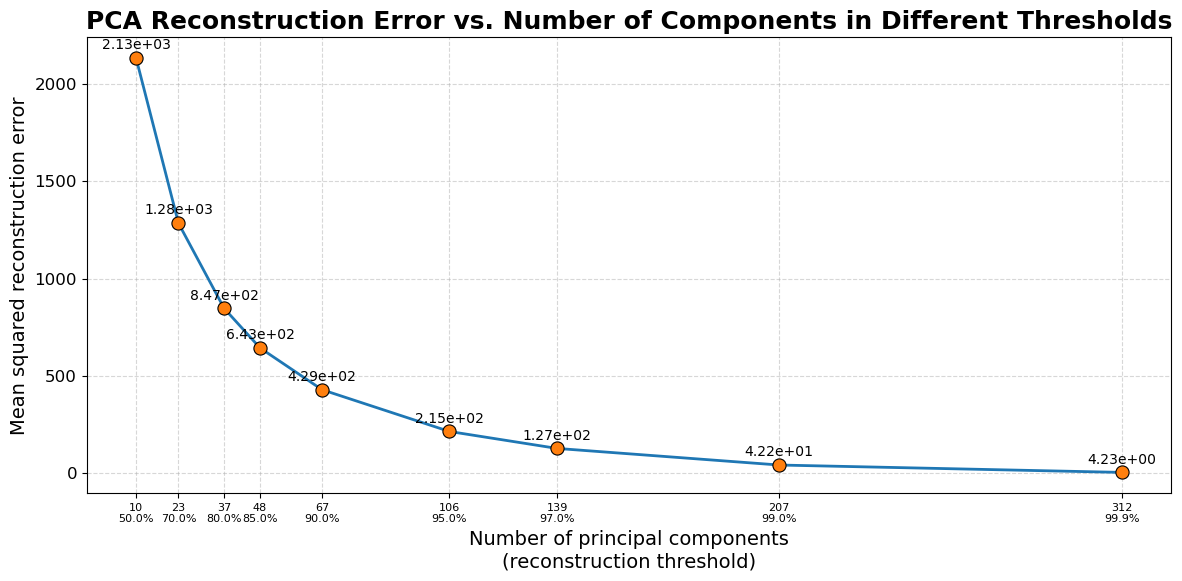

In [ ]:
t_list = [0.50, 0.70, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99, 0.999]
d_list, error_list = PCA(X, t_list, [])
print("手动实现 PCA 的重构误差：", error_list)

threshold_labels = [f"{t:.1%}" for t in t_list]
xtick_labels = [f"{d}\n{th}" for d, th in zip(d_list, threshold_labels)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(d_list, error_list, marker = 'o', markersize = 8, linewidth = 2, color = '#1f77b4')
ax.scatter(d_list, error_list, s = 90, color = '#ff7f0e', edgecolors = 'k', linewidths = 0.8, zorder = 3)

ax.set_title('PCA Reconstruction Error vs. Number of Components in Different Thresholds', fontsize = 18, weight = 'bold')
ax.set_xlabel('Number of principal components\n(reconstruction threshold)', fontsize = 14)
ax.set_ylabel('Mean squared reconstruction error', fontsize = 14)
ax.set_xticks(d_list)
ax.set_xticklabels(xtick_labels, fontsize = 8)
ax.grid(True, linestyle = '--', alpha = 0.5)

for x_val, y_val in zip(d_list, error_list):
    ax.text(x_val, y_val + 30, f'{y_val:.2e}', ha = 'center', va = 'bottom', fontsize = 10)
fig.tight_layout()
fig.savefig('./img/error_dimension.png', dpi = 300)
plt.show()

### 使用PCA算法降到两维并可视化

d_list:  [2]
PCA降到两维的重构误差: 3546.4101


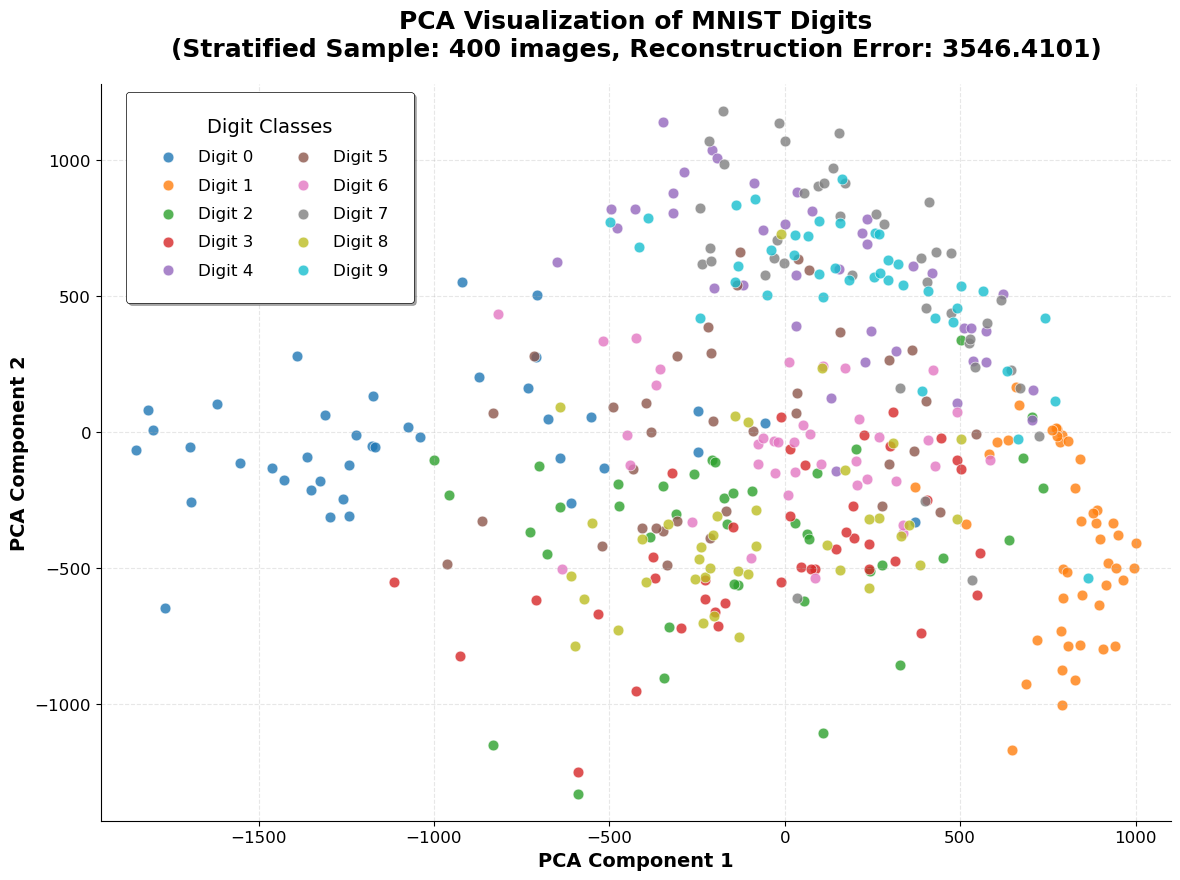

In [ ]:
PCA_error, X_reduced = PCA(X, [], [2])
print(f"PCA降到两维的重构误差: {PCA_error:.4f}")

fig, ax = plt.subplots(figsize = (12, 9))

# 为每个类别创建散点图
for i in range(10):
    mask = y == i
    ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1],
               c = colors[i], s = 60, alpha = 0.8, edgecolors = 'white',
               linewidth = 0.5, label = f'Digit {i}')

# 设置标题和轴标签
ax.set_title(f'PCA Visualization of MNIST Digits\n(Stratified Sample: 400 images, Reconstruction Error: {PCA_error:.4f})',
             fontsize = 18, fontweight = 'bold', pad = 20)
ax.set_xlabel('PCA Component 1', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('PCA Component 2', fontsize = 14, fontweight = 'bold')

# 添加网格
ax.grid(True, alpha = 0.3, linestyle = '--')

# 设置轴的范围和刻度
ax.set_xlim(X_reduced[:, 0].min() - 100, X_reduced[:, 0].max() + 100)
ax.set_ylim(X_reduced[:, 1].min() - 100, X_reduced[:, 1].max() + 100)

# 图例
legend = ax.legend(loc = 'upper right', bbox_to_anchor = (0.3, 1),
                   fontsize = 12, frameon = True, fancybox = True,
                   shadow = True, ncol = 2, title = 'Digit Classes',
                   title_fontsize = 14, borderpad = 1.5, labelspacing = 0.8)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.5)

# 移除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置刻度字体大小
ax.tick_params(axis = 'both', which = 'major', labelsize = 12)

plt.tight_layout()
plt.show()
fig.savefig('./img/pca_2_pro.png', dpi = 300, bbox_inches = 'tight')

### t-SNE 算法实现

In [ ]:
X_reduced = None

def distance(X):
    '''
    计算各样本之间的欧氏距离矩阵 dist
    X: 样本数据
    '''
    n, d = np.shape(X)
    sum_x = np.sum(np.square(X), axis = 1)
    dist = np.add(np.add(-2 * np.dot(X, X.T), sum_x).T, sum_x)
    return dist.astype(np.float64)

def prob_H(dist, index = 0, beta = 1.0):
    '''
    计算某一样本点的概率分布 prob 以及熵 H
    dist: 到该样本点的距离矩阵
    index: 该样本点的索引
    beta: 高斯分布参数 1 / (2 * sigma^2)
    '''
    # 对距离矩阵进行归一化
    dist /= np.max(dist)
    prob = np.exp(-dist * beta)
    prob = np.maximum(prob, 1e-12)
    # 设置自己的概率为 0
    prob[index] = 0
    sum_prob = np.sum(prob)
    H = np.log(sum_prob) + beta * np.sum(dist * prob) / sum_prob
    prob /= sum_prob
    return prob, H

def seach_prob(X, tol = 1e-5, perp = 30.0):
    '''
    在给定的困惑度 perp 下，二分搜索寻找每个样本点对应的高斯分布参数 beta ，并计算总体的概率分布 all_prop
    X: 样本数据
    tol: 搜索精度
    perp: 预先给定的困惑度(5 ~ 50)
    '''
    
    # 初始化参数
    n, d = np.shape(X)
    dist = distance(X)
    all_prob = np.zeros((n, n))
    beta = np.ones((n, 1))      # 高斯分布参数
    H0 = np.log(perp)       # 以熵的差距来搜索
 
    for i in range(n):
        # 初始化上下界
        betamin = -np.inf
        betamax = np.inf
        prob, H = prob_H(dist[i], i, beta[i])
 
        # 二分搜索，寻找对应 prep 下的 beta 和 prob
        diff = H - H0
        loop = 0        # 搜索次数
        while np.abs(diff) > tol and loop < 50:
            if diff > 0:
                betamin = beta[i].copy()
                if betamax == np.inf or betamax == -np.inf:
                    beta[i] = beta[i] * 2
                else:
                    beta[i] = (beta[i] + betamax) / 2
            else:
                betamax = beta[i].copy()
                if betamin == np.inf or betamin == -np.inf:
                    beta[i] = beta[i] / 2
                else:
                    beta[i] = (beta[i] + betamin) / 2
 
            # 更新 perb, prob 值
            prob, H = prob_H(dist[i], i, beta[i])
            diff = H - H0
            loop += 1
        # 记录 prob 值
        all_prob[i, ] = prob
    return all_prob

def tsne(X, dim = 2, perp = 30.0, tol = 1e-5, max_iter = 10000):
    """
    t-SNE 算法主体函数，主要执行梯度下降的迭代过程，从而计算出最小化 KL 散度损失时降维后的样本数据
    X: 样本数据
    dim: 目标维度
    perp: 给定困惑度
    max_iter: 最大迭代次数
    """
 
    # 初始化参数和变量
    n, d = np.shape(X)
    iter = 0        # 迭代次数
    eta = 500       # 学习率
    cost_old = 0.0      # 10 轮前迭代的损失值
    cost_new = 0.0      # 当前轮迭代的损失值
    cost_delta = 1.0        # 前后两次迭代损失值的变化量
    initial_momentum = 0.5      # 前期动量参数
    final_momentum = 0.8        # 后期动量参数
    y = np.random.randn(n, dim)     # 随机生成低维数据
    gradient = np.zeros((n, dim))       # KL 散度损失的梯度
    delta_y = np.zeros((n, dim))        # 低维样本每次迭代的变化量

    # 迭代前预处理
    P = seach_prob(X, 1e-5, perp)
    P = P + np.transpose(P)     # 对称化
    P = P / np.sum(P)       # 归一化
    P = P * 4       # 提前夸大
    P = np.maximum(P, 1e-12)        # 避免后续计算数值下溢

    # 梯度下降
    while iter < max_iter and cost_delta > tol:
        # 计算降维后样本点的概率分布
        sum_y = np.sum(np.square(y), axis = 1)
        q_prob = 1 / (1 + np.add(np.add(-2 * np.dot(y, y.T), sum_y).T, sum_y))
        q_prob[range(n), range(n)] = 0      # 设置自己的概率为 0 
        Q = q_prob / np.sum(q_prob)
        Q = np.maximum(Q, 1e-12)        # 避免后续计算数值下溢
 
        # 计算 KL 散度损失函数的梯度
        PQ = P - Q
        for i in range(n):
            gradient[i, :] = np.sum(np.tile(PQ[: , i] * q_prob[: , i], (dim, 1)).T * (y[i, :] - y), axis = 0)
 
        # 迭代更新低维样本数据
        if iter < 100:
            momentum = initial_momentum
        else:
            momentum = final_momentum
        delta_y = momentum * delta_y - eta * gradient
        y = y + delta_y
        y = y - np.tile(np.mean(y, axis = 0), (n, 1))       # 中心化

        # 计算迭代过程中的损失
        if (iter + 1) % 10 == 0:
            cost_old = cost_new
            if iter > 100:
                cost_new = (np.sum(P * np.log(P / Q))).astype("float")
            else:
                cost_new = np.sum(P/4 * np.log(P/4 / Q)).astype("float")
            cost_delta = abs(cost_new - cost_old)
            print("Iteration", (iter + 1), ": error is ", cost_new)
        # 迭代一定次数后还原
        if iter == 100:
            P = P / 4
        iter += 1
    print("finished")
    print("iter:", iter)
    return y, iter, cost_new

### 不同困惑度下的t-SNE降维结果对比

t-SNE 不同困惑度下的迭代次数： [9760, 6810, 4700, 3310, 2170, 90]
t-SNE 不同困惑度下的成本： [np.float64(0.5795674595742548), np.float64(0.6291717091419933), np.float64(0.6526580362013801), np.float64(0.6479774208609399), np.float64(0.6444835189563995), np.float64(2.02570457786445)]


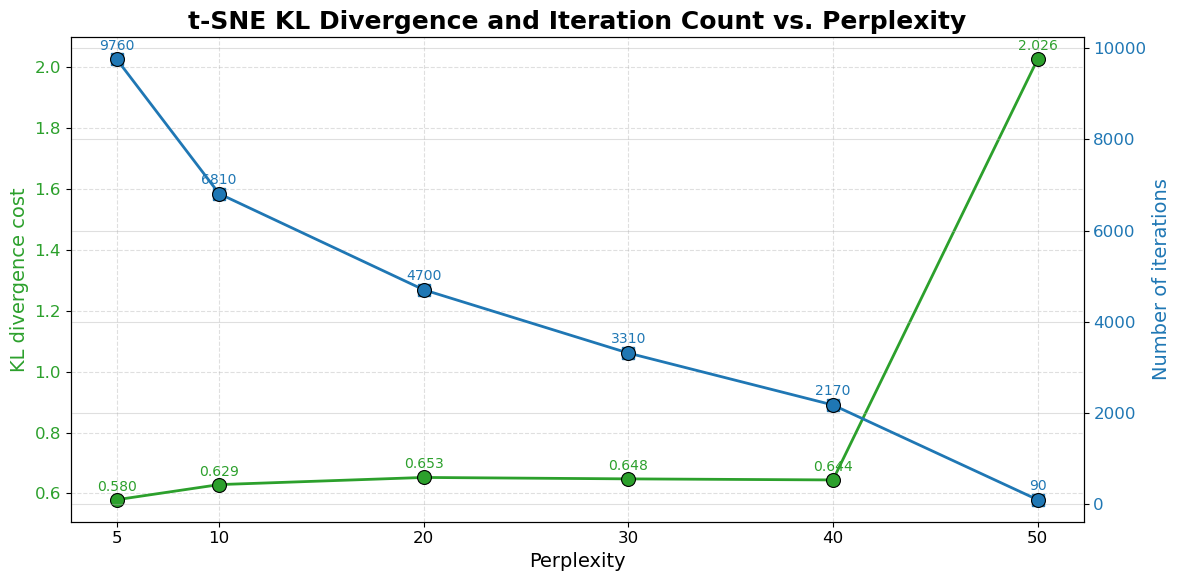

In [ ]:
perps = [5, 10, 20, 30, 40, 50]
iters = []
costs = []
for perp in perps:
    X_reduced, iter, cost = tsne(X, dim = 2, perp = perp)
    iters.append(iter)
    costs.append(cost)
print("t-SNE 不同困惑度下的迭代次数：", iters)
print("t-SNE 不同困惑度下的成本：", costs)

fig, ax1 = plt.subplots(figsize = (12, 6))
ax1.plot(perps, costs, marker = 'o', markersize = 8, linewidth = 2, color = '#2ca02c', label = 'KL divergence')
ax1.scatter(perps, costs, s = 100, color = '#2ca02c', edgecolors = 'k', linewidths = 0.8, zorder = 3)

ax1.set_title('t-SNE KL Divergence and Iteration Count vs. Perplexity', fontsize = 18, weight = 'bold')
ax1.set_xlabel('Perplexity', fontsize = 14)
ax1.set_ylabel('KL divergence cost', fontsize = 14, color = '#2ca02c')
ax1.tick_params(axis = 'y', labelcolor = '#2ca02c')
ax1.set_xticks(perps)
ax1.grid(True, linestyle = '--', alpha = 0.4)

ax2 = ax1.twinx()
ax2.plot(perps, iters, marker = 's', markersize = 8, linewidth = 2, color = '#1f77b4', label = 'Iterations')
ax2.scatter(perps, iters, s = 100, color = '#1f77b4', edgecolors = 'k', linewidths = 0.8, zorder = 3)
ax2.set_ylabel('Number of iterations', fontsize = 14, color = '#1f77b4')
ax2.tick_params(axis = 'y', labelcolor = '#1f77b4')

for x_val, y_val in zip(perps, costs):
    ax1.text(x_val, y_val + 0.02, f'{y_val:.3f}', ha = 'center', va = 'bottom', fontsize = 10, color = '#2ca02c')
for x_val, y_val in zip(perps, iters):
    ax2.text(x_val, y_val + 150, f'{y_val}', ha = 'center', va = 'bottom', fontsize = 10, color = '#1f77b4')

fig.tight_layout()
fig.savefig('./img/perplexity_cost_iteration.png', dpi = 300)
plt.show()

### 使用t-SNE算法降到2维并可视化

Iteration 10 : error is  2.1942515387276718
Iteration 20 : error is  2.2002960359482846
Iteration 30 : error is  2.1924278573601566
Iteration 40 : error is  2.1822300073687306
Iteration 50 : error is  2.1705943091178552
Iteration 60 : error is  2.1828635779364465
Iteration 70 : error is  2.1782445721536856
Iteration 80 : error is  2.1834032265628696
Iteration 90 : error is  2.201208425401876
Iteration 100 : error is  2.2017111478328912
Iteration 110 : error is  1.138434548641225
Iteration 120 : error is  0.8231737814736013
Iteration 130 : error is  0.7607959467889076
Iteration 140 : error is  0.7332140256214431
Iteration 150 : error is  0.716206643220572
Iteration 160 : error is  0.7049313684990786
Iteration 170 : error is  0.6960940348154848
Iteration 180 : error is  0.6891961242405593
Iteration 190 : error is  0.6835327750903626
Iteration 200 : error is  0.6787958946591044
Iteration 210 : error is  0.6747606678826017
Iteration 220 : error is  0.6713616725627558
Iteration 230 : error 

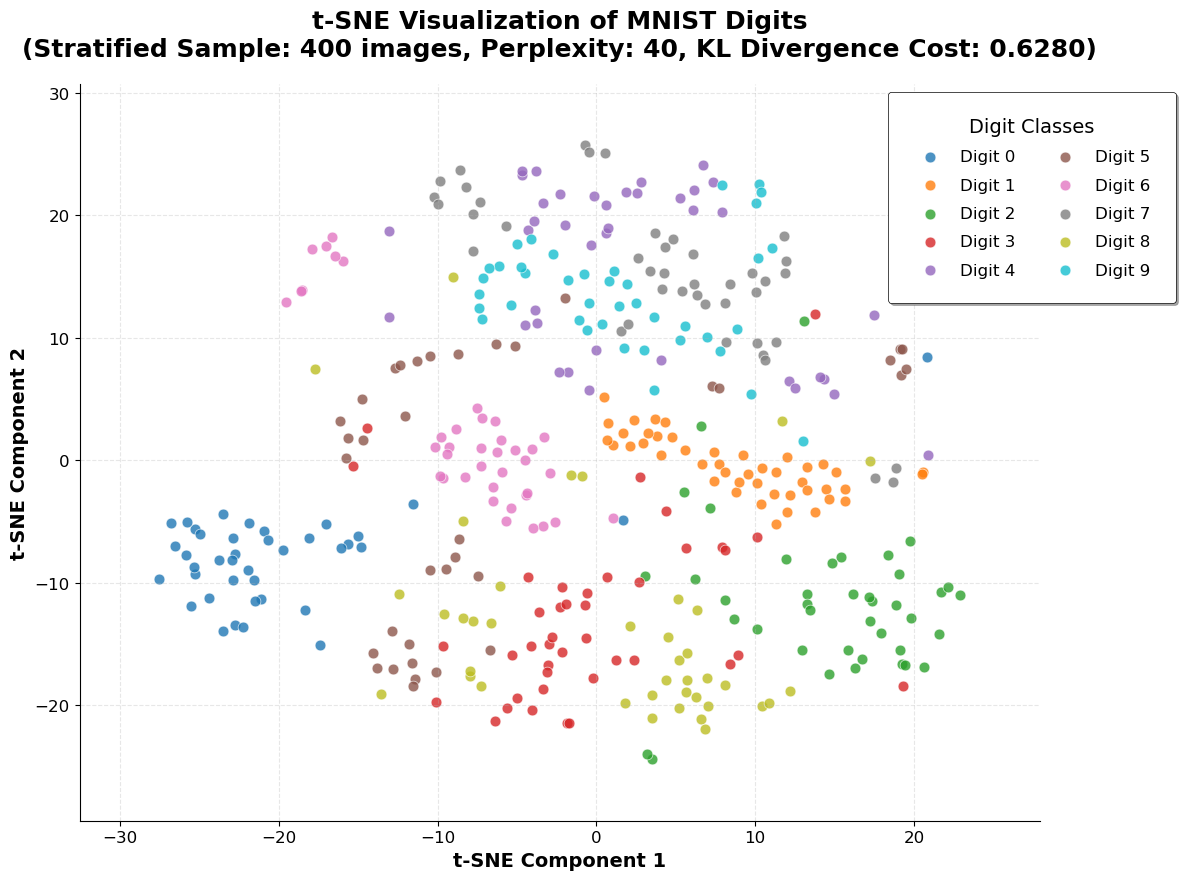

In [ ]:
X_reduced, iter, tsne_cost = tsne(X, dim = 2, perp = 40)
print(f"t-SNE降到两维的KL散度损失: {tsne_cost:.4f}")
print(f"t-SNE降到两维的迭代次数: {iter}")

fig, ax = plt.subplots(figsize = (12, 9))

# 为每个类别创建散点图
for i in range(10):
    mask = y == i
    ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1],
               c = colors[i], s = 60, alpha = 0.8, edgecolors = 'white',
               linewidth = 0.5, label = f'Digit {i}')

# 设置标题和轴标签
ax.set_title(f't-SNE Visualization of MNIST Digits\n(Stratified Sample: 400 images, Perplexity: 40, KL Divergence Cost: {tsne_cost:.4f})',
             fontsize = 18, fontweight = 'bold', pad = 20)
ax.set_xlabel('t-SNE Component 1', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('t-SNE Component 2', fontsize = 14, fontweight = 'bold')

# 添加网格
ax.grid(True, alpha = 0.3, linestyle = '--')

# 设置轴的范围和刻度
ax.set_xlim(X_reduced[:, 0].min() - 5, X_reduced[:, 0].max() + 5)
ax.set_ylim(X_reduced[:, 1].min() - 5, X_reduced[:, 1].max() + 5)

# 图例
legend = ax.legend(loc = 'upper right', bbox_to_anchor = (1.15, 1),
                   fontsize = 12, frameon = True, fancybox = True,
                   shadow = True, ncol = 2, title = 'Digit Classes',
                   title_fontsize = 14, borderpad = 1.5, labelspacing = 0.8)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.5)

# 移除顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置刻度字体大小
ax.tick_params(axis = 'both', which = 'major', labelsize = 12)

plt.tight_layout()
plt.show()
fig.savefig('./img/tsne_2_pro.png', dpi = 300, bbox_inches = 'tight')